In [1]:
import anndata
import numpy as np
import pandas as pd
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse

In [2]:
segmentation_path = Path("/Users/janzules/Roselab/Spatial/CAR_T/data/cell_segmentation/")
adata_file     = segmentation_path / "concatenated" / "combined_adata.h5ad"
geneList = segmentation_path / "Gene_lists"
fig_out = Path("/Users/janzules/Roselab/Spatial/CAR_T/figures/clustering_results/")
ST_sample_org = sc.read_h5ad(adata_file)

# Processing data

In [3]:
# parameter choices
min_UMI = 100
n_cells = 40000 # Random choice
HVG_num = 600 #default 2k

In [4]:
# Cleaning
# Identify mitochondrial genes (prefix 'MT-' for human)
ST_sample_org.var['mito'] = ST_sample_org.var_names.str.startswith('mt-')

#  Run QC metrics
sc.pp.calculate_qc_metrics(
    ST_sample_org, 
    qc_vars=['mito'], 
    inplace=True, 
    log1p=False
)

In [5]:
sc.pp.filter_genes(ST_sample_org, min_cells=10)
# sc.pp.filter_cells(ST_sample_org, min_genes = 100)
ST_sample_org = ST_sample_org[
    (ST_sample_org.obs['total_counts'] >= min_UMI) &
    (ST_sample_org.obs['pct_counts_mito'] <= 15)
].copy()

In [19]:
ST_sample_org.shape

(133945, 14186)

## Sub_sampling_profiling


In [7]:
ST_sample_org.obs['mouse'].unique()

['RTCyT72_2_1', 'RTCyPSCA_1_4', 'CyPSCA_1_1', 'NoTx_2_2', 'CyPSCA_1_2', 'RTCyT72_2_4', 'RTCyPSCA_2_4', 'CyT72_1_4']
Categories (8, object): ['CyPSCA_1_1', 'CyPSCA_1_2', 'CyT72_1_4', 'NoTx_2_2', 'RTCyPSCA_1_4', 'RTCyPSCA_2_4', 'RTCyT72_2_1', 'RTCyT72_2_4']

In [8]:
ST_sample_org.shape

(133945, 14186)

In [18]:
# ST_subset = ST_sample_org[ST_sample_org.obs['mouse'].isin(['RTCyPSCA_1_4'])].copy()
# ST_subset.shape
ST_sample = ST_sample_org[ST_sample_org.obs['mouse'].isin(['RTCyPSCA_1_4', 'RTCyPSCA_2_4'])].copy()
print(f"{ST_sample.shape}")



(23243, 14186)


In [25]:
# Saving count data
ST_sample.layers["counts"] = ST_sample.X.copy()

# GLP1R Analysis

In [29]:
gene = "Glp1r"
gidx = ST_sample.var_names.get_loc(gene)

# Get counts column
col = ST_sample.layers["counts"][:, gidx]
if issparse(col):
    col = col.toarray().ravel()
else:
    col = np.asarray(col).ravel()

# Subset AnnData to cells with > 0 counts
ST_sample_Glp1r = ST_sample[col > 0].copy()
print(f" {ST_sample_Glp1r.shape[0]} are Glp1r+")

 372 are Glp1r+


In [60]:
import scanpy as sc

# 1) Define your marker list
mac_genes_glp1r = [
    "Ptprc","Adgre1","Csf1r","Cd68","Cd74","H2-Ab1",
    "Itgam","S100a9","S100a8","Arg1","Mrc1","Nos2","Tnf","Il1b", "Spp1"
]

# Keep only genes present in the subset
genes_present = [g for g in mac_genes if g in ST_sample_sub.var_names]
 

In [21]:
print(f"mac_genes length: {len(mac_genes)}")
print(f"genes_present length: {len(genes_present)}")

mac_genes length: 15
genes_present length: 15


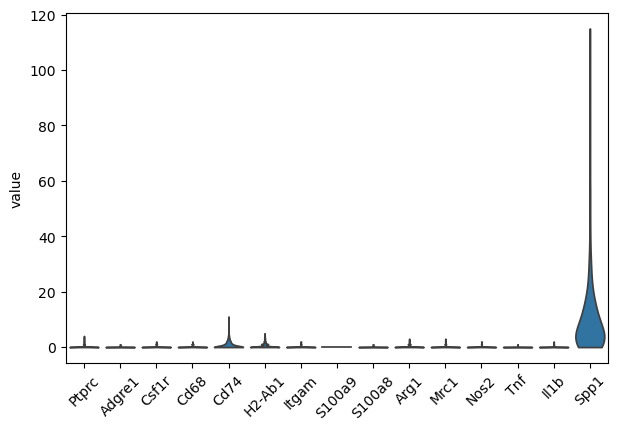

In [22]:
#  Plot violins from raw counts layer (no normalization)
#    NOTE: use_raw=False to force using the specified layer.
sc.pl.violin(
    ST_sample_sub,
    keys=genes_present,
    use_raw=False,
    layer="counts",
    groupby=None,        # overall distribution; set to "leiden" if you want by cluster
    stripplot=False,     # cleaner violins; set True to show individual points
    jitter=0,
    rotation=45
)

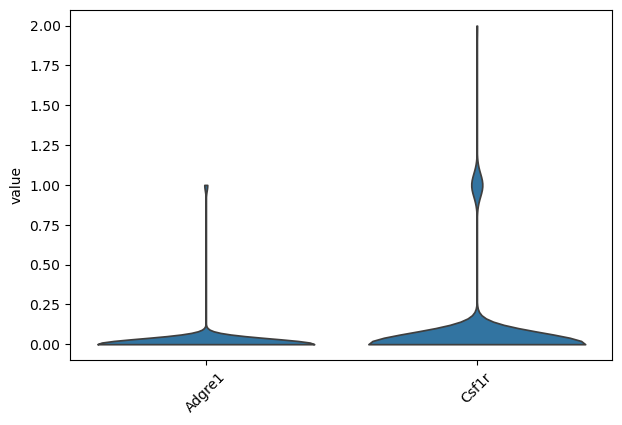

In [32]:
# Plot violins from raw counts layer
sc.pl.violin(
    ST_sample_sub,
    keys=["Adgre1", "Csf1r"],
    layer="counts",
    groupby=None,        # overall distribution; set to "leiden" if you want by cluster
    stripplot=False,     # cleaner violins; set True to show individual points
    jitter=0,
    rotation=45
)

In [ ]:
genes_present.remove("Spp1")

In [138]:
ST_sample_sub.shape

(60, 14186)

In [33]:
import numpy as np
from scipy.sparse import issparse

def get_counts(adata, gene, layer="counts"):
    """Return 1D float array of counts for `gene`. If gene is absent, return zeros."""
    if gene not in adata.var_names:
        return np.zeros(adata.n_obs, dtype=float)
    j = adata.var_names.get_loc(gene)
    v = adata.layers[layer][:, j]
    v = v.toarray().ravel() if issparse(v) else np.asarray(v).ravel()
    return v.astype(float)

genes = ["Glp1r","Ptprc","Csf1r","Adgre1","Cd68","Lyz2",
         "Ms4a1","Cd79a","Cd19","Itgax","H2-Ab1","Cd74","Spp1","Cd36"]

c = {g: get_counts(ST_sample_sub, g, layer="counts") for g in genes}

# --- Gates ---
mask_glp1r = c["Glp1r"] > 0

# macrophage: Csf1r & (Adgre1 or Cd68 or Lyz2) & Ptprc
mask_mac   = (c["Csf1r"]>0) & ((c["Adgre1"]>0)|(c["Cd68"]>0)|(c["Lyz2"]>0)) & (c["Ptprc"]>0)

# exclude obvious B cells / DCs if desired
mask_bcell = (c["Ms4a1"]>0)|(c["Cd79a"]>0)|(c["Cd19"]>0)
mask_dc    = (c["Itgax"]>0)

# supportive signals sometimes seen with GLP1R+ myeloid (paper you shared)
mask_support = (c["Spp1"]>0)|(c["Cd36"]>0)

mask_glp1r_mac = mask_glp1r & mask_mac & ~mask_bcell & ~mask_dc

n = ST_sample_sub.n_obs
print(f"GLP1R+ cells: {int(mask_glp1r.sum())}/{n} ({mask_glp1r.mean()*100:.3f}%)")
print(f"Gated GLP1R+ macrophages: {int(mask_glp1r_mac.sum())}/{n} ({mask_glp1r_mac.mean()*100:.3f}%)")
print(f"APC-high among GLP1R+ macrophages: {int((mask_glp1r_mac & (c['Cd74']>0) & (c['H2-Ab1']>0)).sum())}")
print(f"Support (Spp1 or Cd36) among GLP1R+ macrophages: {int((mask_glp1r_mac & mask_support).sum())}")


GLP1R+ cells: 372/372 (100.000%)
Gated GLP1R+ macrophages: 2/372 (0.538%)
APC-high among GLP1R+ macrophages: 1
Support (Spp1 or Cd36) among GLP1R+ macrophages: 2


## Counting

In [56]:
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt

def detect_counts_table(adata, genes, layer="counts", min_count=1):
    # keep only present genes, preserve order
    var_index = pd.Index(adata.var_names)
    genes = [g for g in genes if g in var_index]
    if not genes:
        raise ValueError("None of the requested genes are in adata.var_names.")

    # choose matrix
    X = adata.layers[layer] if (layer and layer in adata.layers) else adata.X
    idx = var_index.get_indexer(genes)
    # print(idx)
    # count cells/spots with expression >= min_count
    if sparse.issparse(X):
        Xg = X[:, idx]
        n_pos = np.asarray((Xg >= min_count).sum(axis=0)).ravel()
    else:
        Xg = X[:, idx]
        n_pos = (Xg >= min_count).sum(axis=0)
    # print(n_pos)
    n_cells = adata.n_obs
    out = pd.DataFrame({
        "gene": genes,
        "n_cells": n_pos,
        "pct_cells": n_pos * 100.0 / n_cells,
    }).sort_values("n_cells", ascending=False, ignore_index=True)
    return out

tbl = detect_counts_table(ST_sample_Glp1r, genes_present, layer="counts", min_count=1)
print(tbl)

      gene  n_cells   pct_cells
0    Glp1r      372  100.000000
1     Cd74      119   31.989247
2   H2-Ab1       96   25.806452
3     Arg1       38   10.215054
4     Cd68       25    6.720430
5    Ptprc       24    6.451613
6     Mrc1       21    5.645161
7    Csf1r       19    5.107527
8    Itgam       19    5.107527
9     Nos2       15    4.032258
10    Il1b        8    2.150538
11  Adgre1        5    1.344086
12  S100a8        5    1.344086
13     Tnf        3    0.806452
14  S100a9        0    0.000000


      gene  n_cells  pct_cells
0     Spp1      335  90.053763
1     Cd74      119  31.989247
2   H2-Ab1       96  25.806452
3     Arg1       38  10.215054
4     Cd68       25   6.720430
5    Ptprc       24   6.451613
6     Mrc1       21   5.645161
7    Csf1r       19   5.107527
8    Itgam       19   5.107527
9     Nos2       15   4.032258
10    Il1b        8   2.150538
11  Adgre1        5   1.344086
12  S100a8        5   1.344086
13     Tnf        3   0.806452
14  S100a9        0   0.000000


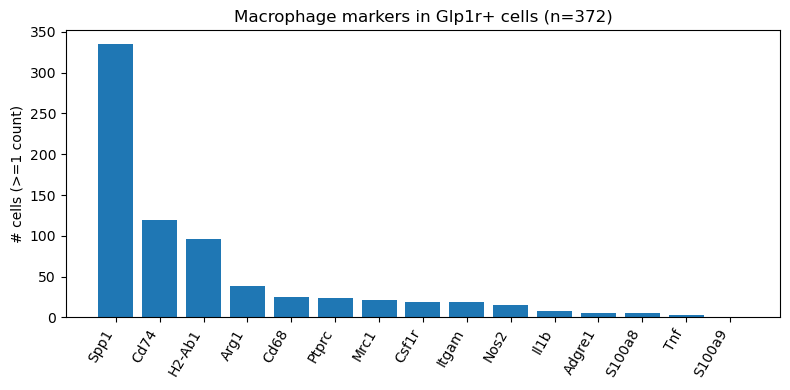

In [66]:
tbl_glp1r = detect_counts_table(ST_sample_Glp1r, mac_genes_glp1r, layer="counts", min_count=1)
print(tbl_glp1r)

# Plot
plt.figure(figsize=(8, 4))
plt.bar(tbl_glp1r["gene"], tbl_glp1r["n_cells"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("# cells (>=1 count)")
plt.title(f"Macrophage markers in Glp1r+ cells (n={ST_sample_sub.n_obs})")
plt.tight_layout()
plt.show()

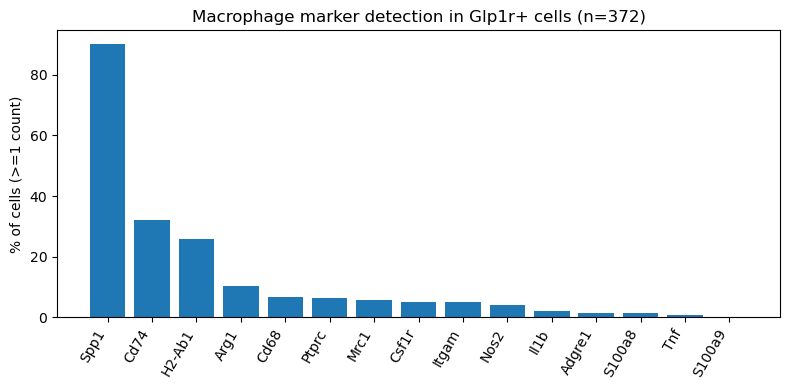

In [67]:
# Plot
plt.figure(figsize=(8, 4))
plt.bar(tbl_glp1r["gene"], tbl_glp1r["pct_cells"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("% of cells (>=1 count)")
plt.title(f"Macrophage marker detection in Glp1r+ cells (n={ST_sample_sub.n_obs})")
plt.tight_layout()
plt.show()

# SPP1 Analysis

In [16]:
ST_sample.shape

(23243, 14186)

In [41]:
from scipy.sparse import issparse
import numpy as np

gene = "Spp1"
gidx = ST_sample.var_names.get_loc(gene)

# Get counts column
col = ST_sample.layers["counts"][:, gidx]
if issparse(col):
    col = col.toarray().ravel()
else:
    col = np.asarray(col).ravel()

# Subset AnnData to cells with > 0 counts
ST_sample_spp1 = ST_sample[col > 0].copy()


In [42]:
ST_sample_spp1.shape

(15394, 14186)

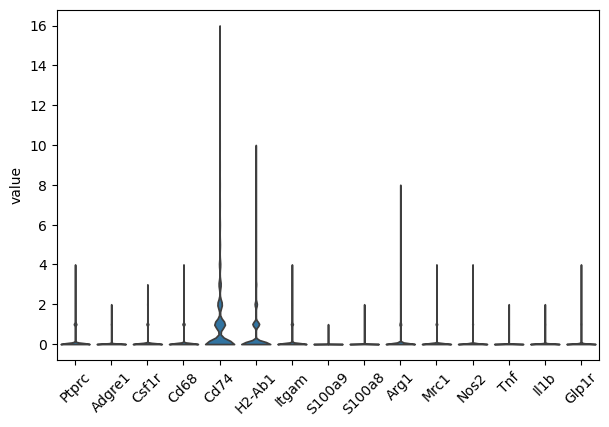

In [63]:
import scanpy as sc

# 1) Define your marker list
mac_genes_spp1 = [
    "Ptprc","Adgre1","Csf1r","Cd68","Cd74","H2-Ab1",
    "Itgam","S100a9","S100a8","Arg1","Mrc1","Nos2","Tnf","Il1b", "Glp1r"
]

# 2) Keep only genes present in the subset
genes_present = [g for g in mac_genes if g in ST_sample_spp1.var_names]
if not genes_present:
    raise ValueError("None of the requested macrophage genes are in ST_sample_sub.var_names.")

# 3) Plot violins from raw counts layer (no normalization)
#    NOTE: use_raw=False to force using the specified layer.
sc.pl.violin(
    ST_sample_spp1,
    keys=genes_present,
    use_raw=False,
    layer="counts",
    groupby=None,        # overall distribution; set to "leiden" if you want by cluster
    stripplot=False,     # cleaner violins; set True to show individual points
    jitter=0,
    rotation=45
)


      gene  n_cells  pct_cells
0     Cd74     6242  40.548266
1   H2-Ab1     3995  25.951669
2    Ptprc     1321   8.581265
3     Cd68     1090   7.080681
4    Itgam     1069   6.944264
5     Arg1     1043   6.775367
6    Csf1r      935   6.073795
7     Mrc1      766   4.975965
8     Nos2      351   2.280109
9   Adgre1      347   2.254125
10   Glp1r      335   2.176173
11    Il1b      329   2.137196
12     Tnf      112   0.727556
13  S100a8       63   0.409250
14  S100a9        5   0.032480


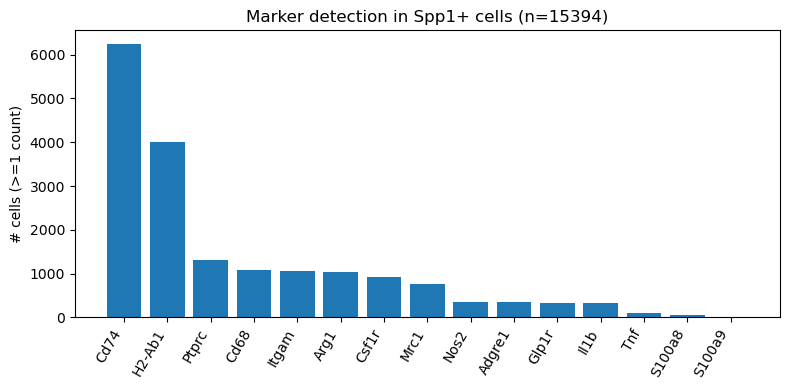

In [64]:
tbl = detect_counts_table(ST_sample_spp1, mac_genes_spp1, layer="counts", min_count=1)
print(tbl)

# Plot
plt.figure(figsize=(8, 4))
plt.bar(tbl["gene"], tbl["n_cells"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("# cells (>=1 count)")
plt.title(f"Macrophage markers in Spp1+ cells (n={ST_sample_spp1.n_obs})")
plt.tight_layout()
plt.show()

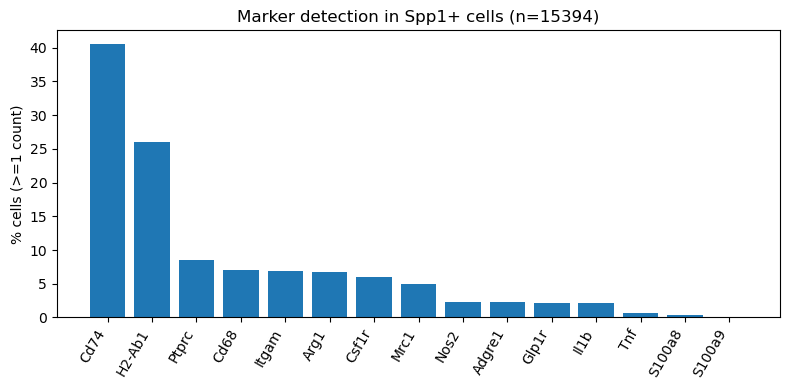

In [65]:
# Plot
plt.figure(figsize=(8, 4))
plt.bar(tbl["gene"], tbl["pct_cells"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("% cells (>=1 count)")
plt.title(f"Marker detection in Spp1+ cells (n={ST_sample_spp1.n_obs})")
plt.tight_layout()
plt.show()

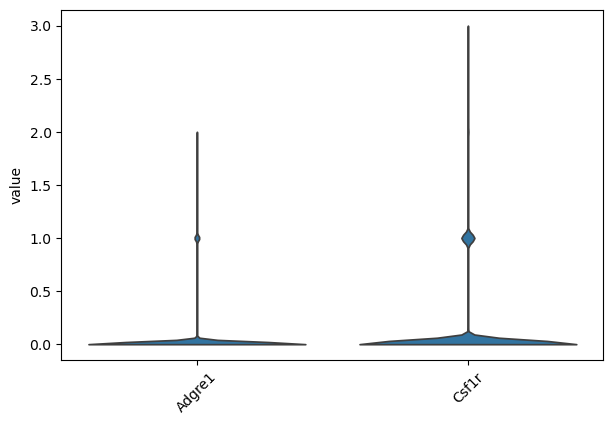

In [44]:
sc.pl.violin(
    ST_sample_spp1,
    keys=["Adgre1", "Csf1r"],
    layer="counts",
    groupby=None,        # overall distribution; set to "leiden" if you want by cluster
    stripplot=False,     # cleaner violins; set True to show individual points
    jitter=0,
    rotation=45
)

In [153]:
43 / 40000

0.001075

In [154]:
ST_sample

AnnData object with n_obs × n_vars = 7808 × 14186
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mouse', 'sample_id', 'condition', 'cx', 'cy', 'TMA', 'total_counts_mito', 'pct_counts_mito', 'S_score', 'G2M_score', 'phase', 'Immune_score', 'leiden', 'Glp1r_posonly'
    var: 'mito', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p', 'pca', 'mouse_colors', 'sample_id_colors', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'condition_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [162]:
ST_sample.columns

AttributeError: 'AnnData' object has no attribute 'columns'

In [17]:
import numpy as np
from scipy.sparse import issparse

adata = ST_sample_spp1
genes = genes_present              # from your code above
layer = "counts"

# Grab the expression matrix to use
X = adata.layers[layer] if layer in adata.layers else adata.X

# Column indices for the genes of interest (order matches `genes`)
gene_idx = [adata.var_names.get_loc(g) for g in genes]

# Slice to the gene set
M = X[:, gene_idx]

# Per-cell: is at least one gene expressed (>0)?
if issparse(M):
    expressed_any = np.asarray((M > 0).sum(axis=1)).ravel() > 0
else:
    expressed_any = (M > 0).sum(axis=1) > 0

# Count cells and also store per-cell flags in obs
n_cells_with_any = int(expressed_any.sum())
adata.obs["mac_any_expressed"] = expressed_any.astype(int)  # 1 = yes, 0 = no

# (Optional) also store how many of the genes are expressed per cell
if issparse(M):
    n_genes_expr = np.asarray((M > 0).sum(axis=1)).ravel()
else:
    n_genes_expr = (M > 0).sum(axis=1)
adata.obs["mac_n_genes_expressed"] = n_genes_expr.astype(int)

print(f"Cells with ≥1 macrophage gene expressed: {n_cells_with_any} / {adata.n_obs} "
      f"({n_cells_with_any/adata.n_obs:.2%})")


Cells with ≥1 macrophage gene expressed: 2987 / 4821 (61.96%)


In [156]:
import squidpy as sq
import scanpy as sc

# make sure coords exist
assert "spatial" in ST_sample.obsm

# build spatial graph
# For Visium/Visium HD spots use coord_type="grid"; otherwise "generic"
sq.gr.spatial_neighbors(ST_sample, coord_type="grid")  # or coord_type="generic"

# Moran’s I for one gene
res = sq.gr.spatial_autocorr(
    ST_sample,
    mode="moran",           # or "geary"
    genes=["Glp1r"],
    n_perms=1000,
    inplace=False           # get a DataFrame back
)
print(res.loc["Glp1r"])


/Users/janzules/anaconda3/envs/spatial_analysis_env_2/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/janzules/anaconda3/envs/spatial_analysis_env_2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


AssertionError: 

# Macrophage Analysis

In [39]:
from scipy.sparse import issparse
import numpy as np
import pandas as pd

# ---- Define marker sets (mouse symbols) ----
mac_lenient = [
    "Tyrobp","Fcer1g","Lst1","Ctss","Ctsb","Lyz2","Lyz1","Aif1","Ms4a7",
    "Csf1r","Adgre1","Itgam","C1qa","C1qb","C1qc","Apoe","Lgals3","Trem2",
    "H2-Ab1","Cd74","Spi1","Mafb"
]
mac_core_require_any = ["Csf1r","Adgre1"]           # optional added specificity
neutrophil_neg = ["Ly6g","Mpo","Elane","S100a8","S100a9","Camp","Ltf"]  # optional guard

In [ ]:
# ---- Choose the matrix to read counts from ----
if "counts" in ST_sample.layers:
    mat = ST_sample.layers["counts"]
else:
    # Fall back to X if counts layer not present
    mat = ST_sample.X

# Convert to dense on-demand
def to_dense(X):
    return X.toarray() if issparse(X) else np.asarray(X)

In [ ]:
# ---- 3) Intersect markers with present genes ----
varnames = ST_sample.var_names
present_lenient = [g for g in mac_lenient if g in varnames]
present_core    = [g for g in mac_core_require_any if g in varnames]
present_neut    = [g for g in neutrophil_neg if g in varnames]

print(f"length lenient present: {len(present_lenient)}")
print(f"length mac_lenient: {len(mac_lenient)}")

present_core



# ---- 4) Build detection matrices ----
len_idx = [varnames.get_loc(g) for g in present_lenient]
len_mat = to_dense(mat[:, len_idx])

# Count how many macrophage markers are detected per cell (UMI > 0)
len_detect = (len_mat > 0).astype(int)
mac_hits = len_detect.sum(axis=1)

# Optional: require at least one core gene (Csf1r or Adgre1) to be detected
if len(present_core) > 0:
    core_idx = [varnames.get_loc(g) for g in present_core]
    core_mat = to_dense(mat[:, core_idx])
    core_any = (core_mat > 0).any(axis=1)
else:
    # If neither core gene is present in data, skip this criterion
    core_any = np.ones(ST_sample.n_obs, dtype=bool)

# Optional neutrophil exclusion if needed
if len(present_neut) > 0:
    neu_idx = [varnames.get_loc(g) for g in present_neut]
    neu_mat = to_dense(mat[:, neu_idx])
    neu_hits = (neu_mat > 0).sum(axis=1)
else:
    neu_hits = np.zeros(ST_sample.n_obs, dtype=int)

# ---- 5) Make masks ----
# Lenient macrophage: detected >= 2 lenient markers
lenient_mask = mac_hits >= 2

# Slightly stricter: lenient + at least one core gene
strict_mask = lenient_mask & core_any

# Optional neutrophil guard: drop cells with >=2 neutrophil markers *and* no core macrophage gene
# (helps when neutrophils are abundant)
neut_guard_mask = ~((neu_hits >= 2) & (~core_any))

# Final masks
mac_lenient_mask = lenient_mask & neut_guard_mask
mac_strict_mask  = strict_mask  & neut_guard_mask

# ---- 6) Save annotations and subset views you can work with ----
ST_sample.obs["mac_marker_hits"] = mac_hits
ST_sample.obs["mac_core_any"]    = core_any
ST_sample.obs["neut_hits"]       = neu_hits
ST_sample.obs["mac_lenient_flag"] = mac_lenient_mask
ST_sample.obs["mac_strict_flag"]  = mac_strict_mask

ST_mac_lenient = ST_sample[mac_lenient_mask].copy()
ST_mac_strict  = ST_sample[mac_strict_mask].copy()

print(f"Macrophage (lenient) cells: {ST_mac_lenient.n_obs}")
print(f"Macrophage (strict) cells:  {ST_mac_strict.n_obs}")

from scipy.sparse import issparse
import numpy as np
import pandas as pd

# ---------- helpers ----------
def _get_counts_col(adata, gene, layer="counts"):
    """Return a dense 1D counts vector for `gene` (case-insensitive fallback)."""
    if gene in adata.var_names:
        idx = adata.var_names.get_loc(gene)
    else:
        upper = np.char.upper(adata.var_names.astype(str))
        hits = np.where(upper == gene.upper())[0]
        if len(hits) == 0:
            return None
        idx = hits[0]
    M = adata.layers[layer] if layer in adata.layers else adata.X
    col = M[:, idx]
    return col.toarray().ravel() if issparse(col) else np.asarray(col).ravel()

def _summarize_mask(glp_det, spp_det, mask, label):
    n = int(mask.sum())
    if n == 0:
        return dict(group=label, N_cells=0,
                    Glp1r_pos_N=0, Glp1r_pos_pct=0.0,
                    Spp1_pos_N=0, Spp1_pos_pct=0.0,
                    both_pos_N=0, both_pos_pct=0.0)
    glp_n  = int((glp_det & mask).sum())
    spp_n  = int((spp_det & mask).sum())
    both_n = int(((glp_det & spp_det) & mask).sum())
    return dict(group=label, N_cells=n,
                Glp1r_pos_N=glp_n, Glp1r_pos_pct=100*glp_n/n,
                Spp1_pos_N=spp_n, Spp1_pos_pct=100*spp_n/n,
                both_pos_N=both_n, both_pos_pct=100*both_n/n)

# ---------- genes & detection (UMI > 0) ----------
g_glp = "Glp1r"
g_spp = "Spp1"

glp = _get_counts_col(ST_sample, g_glp)
spp = _get_counts_col(ST_sample, g_spp)
if glp is None: raise ValueError(f"{g_glp} not found in var_names.")
if spp is None: raise ValueError(f"{g_spp} not found in var_names.")

glp_det  = glp > 0
spp_det  = spp > 0

# Save global detection flags (useful later)
ST_sample.obs["det_Glp1r"] = glp_det
ST_sample.obs["det_Spp1"]  = spp_det
ST_sample.obs["det_both_Glp1r_Spp1"] = glp_det & spp_det

# ---------- masks ----------
if "mac_lenient_flag" not in ST_sample.obs or "mac_strict_flag" not in ST_sample.obs:
    raise ValueError("mac_lenient_flag and/or mac_strict_flag not found in .obs. Create them first.")

m_len = ST_sample.obs["mac_lenient_flag"].to_numpy(dtype=bool)
m_str = ST_sample.obs["mac_strict_flag"].to_numpy(dtype=bool)

# ---------- summaries (overall) ----------
rows = [
    _summarize_mask(glp_det, spp_det, m_len, "mac_lenient"),
    _summarize_mask(glp_det, spp_det, m_str, "mac_strict"),
]
summary_both = pd.DataFrame(rows, columns=[
    "group","N_cells",
    "Glp1r_pos_N","Glp1r_pos_pct",
    "Spp1_pos_N","Spp1_pos_pct",
    "both_pos_N","both_pos_pct"
])
print(summary_both.to_string(index=False))

# ---------- optional: per-mouse breakdown for both groups ----------
if "mouse" in ST_sample.obs:
    def _per_mouse(mask, label):
        df = ST_sample.obs.loc[mask, ["mouse","det_Glp1r","det_Spp1"]].copy()
        df["det_both"] = df["det_Glp1r"] & df["det_Spp1"]
        agg = df.groupby("mouse").agg(
            N=("det_Glp1r","size"),
            Glp1r_pos=("det_Glp1r","sum"),
            Spp1_pos=("det_Spp1","sum"),
            Both_pos=("det_both","sum"),
        )
        agg["Glp1r_%"] = 100*agg["Glp1r_pos"]/agg["N"]
        agg["Spp1_%"]  = 100*agg["Spp1_pos"]/agg["N"]
        agg["Both_%"]  = 100*agg["Both_pos"]/agg["N"]
        agg.insert(0, "group", label)
        return agg.reset_index()

    per_mouse_len = _per_mouse(m_len, "mac_lenient")
    per_mouse_str = _per_mouse(m_str, "mac_strict")
    per_mouse_both = pd.concat([per_mouse_len, per_mouse_str], ignore_index=True)
    print("\nPer-mouse breakdown:")
    print(per_mouse_both.to_string(index=False))

In [37]:
from scipy.sparse import issparse
import numpy as np
import pandas as pd

# ---------- helpers ----------
def _get_counts_col(adata, gene, layer="counts"):
    """Return a dense 1D counts vector for `gene` (case-insensitive fallback)."""
    if gene in adata.var_names:
        idx = adata.var_names.get_loc(gene)
    else:
        upper = np.char.upper(adata.var_names.astype(str))
        hits = np.where(upper == gene.upper())[0]
        if len(hits) == 0:
            return None
        idx = hits[0]
    M = adata.layers[layer] if layer in adata.layers else adata.X
    col = M[:, idx]
    return col.toarray().ravel() if issparse(col) else np.asarray(col).ravel()

def _summarize_mask(glp_det, spp_det, mask, label):
    n = int(mask.sum())
    if n == 0:
        return dict(group=label, N_cells=0,
                    Glp1r_pos_N=0, Glp1r_pos_pct=0.0,
                    Spp1_pos_N=0, Spp1_pos_pct=0.0,
                    both_pos_N=0, both_pos_pct=0.0)
    glp_n  = int((glp_det & mask).sum())
    spp_n  = int((spp_det & mask).sum())
    both_n = int(((glp_det & spp_det) & mask).sum())
    return dict(group=label, N_cells=n,
                Glp1r_pos_N=glp_n, Glp1r_pos_pct=100*glp_n/n,
                Spp1_pos_N=spp_n, Spp1_pos_pct=100*spp_n/n,
                both_pos_N=both_n, both_pos_pct=100*both_n/n)

# ---------- genes & detection (UMI > 0) ----------
g_glp = "Glp1r"
g_spp = "Spp1"

glp = _get_counts_col(ST_sample, g_glp)
spp = _get_counts_col(ST_sample, g_spp)
if glp is None: raise ValueError(f"{g_glp} not found in var_names.")
if spp is None: raise ValueError(f"{g_spp} not found in var_names.")

glp_det  = glp > 0
spp_det  = spp > 0

# Save global detection flags (useful later)
ST_sample.obs["det_Glp1r"] = glp_det
ST_sample.obs["det_Spp1"]  = spp_det
ST_sample.obs["det_both_Glp1r_Spp1"] = glp_det & spp_det

# ---------- masks ----------
if "mac_lenient_flag" not in ST_sample.obs or "mac_strict_flag" not in ST_sample.obs:
    raise ValueError("mac_lenient_flag and/or mac_strict_flag not found in .obs. Create them first.")

m_len = ST_sample.obs["mac_lenient_flag"].to_numpy(dtype=bool)
m_str = ST_sample.obs["mac_strict_flag"].to_numpy(dtype=bool)

# ---------- summaries (overall) ----------
rows = [
    _summarize_mask(glp_det, spp_det, m_len, "mac_lenient"),
    _summarize_mask(glp_det, spp_det, m_str, "mac_strict"),
]
summary_both = pd.DataFrame(rows, columns=[
    "group","N_cells",
    "Glp1r_pos_N","Glp1r_pos_pct",
    "Spp1_pos_N","Spp1_pos_pct",
    "both_pos_N","both_pos_pct"
])
print(summary_both.to_string(index=False))

# ---------- optional: per-mouse breakdown for both groups ----------
if "mouse" in ST_sample.obs:
    def _per_mouse(mask, label):
        df = ST_sample.obs.loc[mask, ["mouse","det_Glp1r","det_Spp1"]].copy()
        df["det_both"] = df["det_Glp1r"] & df["det_Spp1"]
        agg = df.groupby("mouse").agg(
            N=("det_Glp1r","size"),
            Glp1r_pos=("det_Glp1r","sum"),
            Spp1_pos=("det_Spp1","sum"),
            Both_pos=("det_both","sum"),
        )
        agg["Glp1r_%"] = 100*agg["Glp1r_pos"]/agg["N"]
        agg["Spp1_%"]  = 100*agg["Spp1_pos"]/agg["N"]
        agg["Both_%"]  = 100*agg["Both_pos"]/agg["N"]
        agg.insert(0, "group", label)
        return agg.reset_index()

    per_mouse_len = _per_mouse(m_len, "mac_lenient")
    per_mouse_str = _per_mouse(m_str, "mac_strict")
    per_mouse_both = pd.concat([per_mouse_len, per_mouse_str], ignore_index=True)
    print("\nPer-mouse breakdown:")
    print(per_mouse_both.to_string(index=False))


      group  N_cells  Glp1r_pos_N  Glp1r_pos_pct  Spp1_pos_N  Spp1_pos_pct  both_pos_N  both_pos_pct
mac_lenient    18907          296       1.565558       12480     66.007299         272      1.438621
 mac_strict     1839           23       1.250680        1237     67.264818          21      1.141925

Per-mouse breakdown:
       mouse       group     N  Glp1r_pos  Spp1_pos  Both_pos  Glp1r_%    Spp1_%   Both_%
RTCyPSCA_1_4 mac_lenient  6341         49      3784        46 0.772749 59.675130 0.725438
RTCyPSCA_2_4 mac_lenient 12566        247      8696       226 1.965622 69.202610 1.798504
RTCyPSCA_1_4  mac_strict   628          5       370         5 0.796178 58.917197 0.796178
RTCyPSCA_2_4  mac_strict  1211         18       867        16 1.486375 71.593724 1.321222


/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_57123/1480632755.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("mouse").agg(
/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_57123/1480632755.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("mouse").agg(


In [36]:
ST_sample.shape

(23243, 14186)

## Processing cells results

In [38]:
import numpy as np
import pandas as pd
from scipy.sparse import issparse

# --- Helper to get dense matrix and safe gene lookup ---
def _dense(A):
    return A.toarray() if issparse(A) else np.asarray(A)

def _get_cols(adata, genes, layer="counts"):
    M = adata.layers[layer] if layer in adata.layers else adata.X
    var = adata.var_names
    keep = [g for g in genes if g in var]
    if not keep:
        return keep, None
    idx = [var.get_loc(g) for g in keep]
    return keep, _dense(M[:, idx])

# --- Recompute key pieces if needed (safe even if already present) ---
mac_lenient = [
    "Tyrobp","Fcer1g","Lst1","Ctss","Ctsb","Lyz2","Lyz1","Aif1","Ms4a7",
    "Csf1r","Adgre1","Itgam","C1qa","C1qb","C1qc","Apoe","Lgals3","Trem2",
    "H2-Ab1","Cd74","Spi1","Mafb"
]
mac_core_require_any = ["Csf1r","Adgre1"]
neutrophil_neg = ["Ly6g","Mpo","Elane","S100a8","S100a9","Camp","Ltf"]

present_len, len_mat = _get_cols(ST_sample, mac_lenient)
present_core, core_mat = _get_cols(ST_sample, mac_core_require_any)
present_neut, neu_mat = _get_cols(ST_sample, neutrophil_neg)

if len_mat is None:
    raise ValueError("No lenient macrophage markers found in var_names.")

mac_hits = (len_mat > 0).astype(int).sum(axis=1)

if core_mat is not None:
    core_any = (core_mat > 0).any(axis=1)
else:
    core_any = np.ones(ST_sample.n_obs, dtype=bool)

if neu_mat is not None:
    neu_hits = (neu_mat > 0).astype(int).sum(axis=1)
else:
    neu_hits = np.zeros(ST_sample.n_obs, dtype=int)

# --- Pre-guard masks (what you'd have BEFORE dropping neutrophil-like cells) ---
pre_lenient = mac_hits >= 2
pre_strict  = pre_lenient & core_any

# --- Neutrophil guard definition (cells to drop) ---
neut_guard_drop = (neu_hits >= 2) & (~core_any)

# --- Post-guard masks (what you keep) ---
post_lenient = pre_lenient & (~neut_guard_drop)
post_strict  = pre_strict  & (~neut_guard_drop)

# --- Save useful flags ---
ST_sample.obs["pre_lenient_flag"] = pre_lenient
ST_sample.obs["pre_strict_flag"]  = pre_strict
ST_sample.obs["neut_guard_drop"]  = neut_guard_drop
ST_sample.obs["mac_lenient_flag"] = post_lenient
ST_sample.obs["mac_strict_flag"]  = post_strict

# --- Summaries ---
def _row(label, pre_mask, post_mask):
    preN  = int(pre_mask.sum())
    postN = int(post_mask.sum())
    dropN = preN - postN
    dropPct = (100.0 * dropN / preN) if preN > 0 else 0.0
    return dict(
        group=label,
        pre_N=preN, post_N=postN, dropped_by_neut_guard_N=dropN,
        dropped_by_neut_guard_pct=dropPct
    )

summary = pd.DataFrame([
    _row("mac_lenient", pre_lenient, post_lenient),
    _row("mac_strict",  pre_strict,  post_strict),
])

print(summary.to_string(index=False))

# --- Optional: per-mouse impact of the guard ---
if "mouse" in ST_sample.obs:
    df = ST_sample.obs[["mouse","pre_lenient_flag","pre_strict_flag","neut_guard_drop"]].copy()
    def _agg(pre_col):
        tab = df.groupby("mouse").agg(
            pre_N=(pre_col, "sum"),
            dropped_N=("neut_guard_drop", lambda x: int((x & df[pre_col]).sum()))
        )
        tab["dropped_%"] = 100.0 * tab["dropped_N"] / tab["pre_N"].clip(lower=1)
        return tab.reset_index()

    per_mouse_len = _agg("pre_lenient_flag");  per_mouse_len.insert(1,"group","mac_lenient")
    per_mouse_str = _agg("pre_strict_flag");   per_mouse_str.insert(1,"group","mac_strict")
    per_mouse = pd.concat([per_mouse_len, per_mouse_str], ignore_index=True)
    print("\nPer-mouse neutrophil-guard impact:")
    print(per_mouse.to_string(index=False))


      group  pre_N  post_N  dropped_by_neut_guard_N  dropped_by_neut_guard_pct
mac_lenient  18907   18907                        0                        0.0
 mac_strict   1839    1839                        0                        0.0

Per-mouse neutrophil-guard impact:
       mouse       group  pre_N  dropped_N  dropped_%
RTCyPSCA_1_4 mac_lenient   6341          0        0.0
RTCyPSCA_2_4 mac_lenient  12566          0        0.0
RTCyPSCA_1_4  mac_strict    628          0        0.0
RTCyPSCA_2_4  mac_strict   1211          0        0.0


/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_57123/1548765683.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby("mouse").agg(
/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_57123/1548765683.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby("mouse").agg(


In [40]:
from scipy.sparse import issparse
import numpy as np
import pandas as pd

# ------------------ 0) Parameters ------------------
MIN_UMI_GLP_SPP = 1           # minimal UMI for Glp1r/Spp1 detection
REQUIRE_CORE_FOR_STRICT = True
USE_DOMINANCE_GUARD = True    # requires mac_hits > neut_hits for both sets
STRICT_DOUBLET_CAP = True     # additionally drop spots with >=2 neut hits from strict
REMOVE_BROAD_APC_FROM_DECISION = True  # don't count MHC-II/B-cell-ish genes toward mac_hits

# ------------------ 1) Marker sets (mouse symbols) ------------------
mac_lenient_all = [
    "Tyrobp","Fcer1g","Lst1","Ctss","Ctsb","Lyz2","Lyz1","Aif1","Ms4a7",
    "Csf1r","Adgre1","Itgam","C1qa","C1qb","C1qc","Apoe","Lgals3","Trem2",
    "H2-Ab1","Cd74","Spi1","Mafb"
]
mac_core_require_any = ["Csf1r","Adgre1"]
neutrophil_markers = ["Ly6g","Mpo","Elane","S100a8","S100a9","Camp","Ltf"]

# Optionally remove broader APC genes from the decision set
broad_apc = {"H2-Ab1","Cd74"}
if REMOVE_BROAD_APC_FROM_DECISION:
    mac_lenient = [g for g in mac_lenient_all if g not in broad_apc]
else:
    mac_lenient = mac_lenient_all

# ------------------ 2) Choose matrix ------------------
if "counts" in ST_sample.layers:
    M = ST_sample.layers["counts"]
else:
    M = ST_sample.X

def to_dense(X):
    return X.toarray() if issparse(X) else np.asarray(X)

varnames = ST_sample.var_names

present_lenient = [g for g in mac_lenient if g in varnames]
present_core    = [g for g in mac_core_require_any if g in varnames]
present_neut    = [g for g in neutrophil_markers if g in varnames]

# ------------------ 3) Build detection counts ------------------
# Mac hits
len_idx = [varnames.get_loc(g) for g in present_lenient]
len_mat = to_dense(M[:, len_idx])
len_detect = (len_mat > 0).astype(int)
mac_hits = len_detect.sum(axis=1)

# Core genes (fail fast if strict is requested but no core genes present)
if REQUIRE_CORE_FOR_STRICT and len(present_core) == 0:
    raise ValueError("No core macrophage genes (Csf1r/Adgre1) present in var_names; cannot form a strict mask.")
if len(present_core) > 0:
    core_idx = [varnames.get_loc(g) for g in present_core]
    core_mat = to_dense(M[:, core_idx])
    core_any = (core_mat > 0).any(axis=1)
else:
    # Only possible when REQUIRE_CORE_FOR_STRICT == False
    core_any = np.ones(ST_sample.n_obs, dtype=bool)

# Neutrophil hits
if len(present_neut) > 0:
    neu_idx = [varnames.get_loc(g) for g in present_neut]
    neu_mat = to_dense(M[:, neu_idx])
    neu_hits = (neu_mat > 0).sum(axis=1)
else:
    neu_hits = np.zeros(ST_sample.n_obs, dtype=int)

# ------------------ 4) Guards & masks ------------------
# Base macrophage criteria (>=2 lenient markers)
base_mac = mac_hits >= 2

# Dominance guard for both sets (default)
if USE_DOMINANCE_GUARD:
    neut_guard = mac_hits > neu_hits
else:
    # alternative permissive guard: simply exclude spots with >=2 neut markers
    neut_guard = neu_hits < 2

# Final masks
mac_lenient_mask = base_mac & neut_guard

if REQUIRE_CORE_FOR_STRICT:
    strict_base = base_mac & core_any
else:
    strict_base = base_mac

if STRICT_DOUBLET_CAP:
    strict_block = neu_hits >= 2
    mac_strict_mask = strict_base & neut_guard & (~strict_block)
else:
    mac_strict_mask = strict_base & neut_guard

# ------------------ 5) Save annotations ------------------
ST_sample.obs["mac_marker_hits"]  = mac_hits
ST_sample.obs["mac_core_any"]     = core_any
ST_sample.obs["neut_hits"]        = neu_hits
ST_sample.obs["mac_lenient_flag"] = mac_lenient_mask
ST_sample.obs["mac_strict_flag"]  = mac_strict_mask

ST_mac_lenient = ST_sample[mac_lenient_mask].copy()
ST_mac_strict  = ST_sample[mac_strict_mask].copy()

print(f"Macrophage (lenient) cells: {ST_mac_lenient.n_obs}")
print(f"Macrophage (strict) cells:  {ST_mac_strict.n_obs}")

# ------------------ 6) Glp1r / Spp1 detection with minimal UMI ------------------
def _get_counts_col(adata, gene, layer="counts"):
    if gene in adata.var_names:
        idx = adata.var_names.get_loc(gene)
    else:
        upper = np.char.upper(adata.var_names.astype(str))
        hits = np.where(upper == gene.upper())[0]
        if len(hits) == 0:
            return None
        idx = hits[0]
    M = adata.layers[layer] if layer in adata.layers else adata.X
    col = M[:, idx]
    return col.toarray().ravel() if issparse(col) else np.asarray(col).ravel()

def _summarize_mask(glp_det, spp_det, mask, label):
    n = int(mask.sum())
    if n == 0:
        return dict(group=label, N_cells=0,
                    Glp1r_pos_N=0, Glp1r_pos_pct=0.0,
                    Spp1_pos_N=0, Spp1_pos_pct=0.0,
                    both_pos_N=0, both_pos_pct=0.0)
    glp_n  = int((glp_det & mask).sum())
    spp_n  = int((spp_det & mask).sum())
    both_n = int(((glp_det & spp_det) & mask).sum())
    return dict(group=label, N_cells=n,
                Glp1r_pos_N=glp_n, Glp1r_pos_pct=100*glp_n/n,
                Spp1_pos_N=spp_n, Spp1_pos_pct=100*spp_n/n,
                both_pos_N=both_n, both_pos_pct=100*both_n/n)

g_glp = "Glp1r"
g_spp = "Spp1"
glp = _get_counts_col(ST_sample, g_glp)
spp = _get_counts_col(ST_sample, g_spp)
if glp is None: raise ValueError(f"{g_glp} not found in var_names.")
if spp is None: raise ValueError(f"{g_spp} not found in var_names.")

# Minimal UMI thresholds for detection
glp_det = glp >= MIN_UMI_GLP_SPP
spp_det = spp >= MIN_UMI_GLP_SPP

ST_sample.obs["det_Glp1r"] = glp_det
ST_sample.obs["det_Spp1"]  = spp_det
ST_sample.obs["det_both_Glp1r_Spp1"] = glp_det & spp_det

# ------------------ 7) Summaries (overall) ------------------
m_len = mac_lenient_mask
m_str = mac_strict_mask

rows = [
    _summarize_mask(glp_det, spp_det, m_len, "mac_lenient"),
    _summarize_mask(glp_det, spp_det, m_str, "mac_strict"),
]
summary_both = pd.DataFrame(rows, columns=[
    "group","N_cells",
    "Glp1r_pos_N","Glp1r_pos_pct",
    "Spp1_pos_N","Spp1_pos_pct",
    "both_pos_N","both_pos_pct"
])
print(summary_both.to_string(index=False))

# ------------------ 8) Optional: per-mouse breakdown ------------------
if "mouse" in ST_sample.obs.columns:
    def _per_mouse(mask, label):
        df = ST_sample.obs.loc[mask, ["mouse","det_Glp1r","det_Spp1"]].copy()
        df["det_both"] = df["det_Glp1r"] & df["det_Spp1"]
        agg = df.groupby("mouse").agg(
            N=("det_Glp1r","size"),
            Glp1r_pos=("det_Glp1r","sum"),
            Spp1_pos=("det_Spp1","sum"),
            Both_pos=("det_both","sum"),
        )
        agg["Glp1r_%"] = 100*agg["Glp1r_pos"]/agg["N"]
        agg["Spp1_%"]  = 100*agg["Spp1_pos"]/agg["N"]
        agg["Both_%"]  = 100*agg["Both_pos"]/agg["N"]
        agg.insert(0, "group", label)
        return agg.reset_index()

    per_mouse_len = _per_mouse(m_len, "mac_lenient")
    per_mouse_str = _per_mouse(m_str, "mac_strict")
    per_mouse_both = pd.concat([per_mouse_len, per_mouse_str], ignore_index=True)
    print("\nPer-mouse breakdown:")
    print(per_mouse_both.to_string(index=False))


Macrophage (lenient) cells: 17553
Macrophage (strict) cells:  1820
      group  N_cells  Glp1r_pos_N  Glp1r_pos_pct  Spp1_pos_N  Spp1_pos_pct  both_pos_N  both_pos_pct
mac_lenient    17553          288       1.640745       11728     66.814789         265      1.509713
 mac_strict     1820           23       1.263736        1222     67.142857          21      1.153846

Per-mouse breakdown:
       mouse       group     N  Glp1r_pos  Spp1_pos  Both_pos  Glp1r_%    Spp1_%   Both_%
RTCyPSCA_1_4 mac_lenient  5752         48      3457        45 0.834492 60.100834 0.782337
RTCyPSCA_2_4 mac_lenient 11801        240      8271       220 2.033726 70.087281 1.864249
RTCyPSCA_1_4  mac_strict   615          5       360         5 0.813008 58.536585 0.813008
RTCyPSCA_2_4  mac_strict  1205         18       862        16 1.493776 71.535270 1.327801


/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_57123/2467805722.py:172: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("mouse").agg(
/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_57123/2467805722.py:172: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("mouse").agg(


In [41]:
import pandas as pd
import numpy as np

# --- define "base" candidate sets before neutrophil filtering ---
lenient_base = (mac_hits >= 2)

# if you required core genes for strict:
strict_base = (mac_hits >= 2) & ST_sample.obs["mac_core_any"].to_numpy(dtype=bool)

# cells removed by neutrophil logic
removed_len_mask = lenient_base & (~ST_sample.obs["mac_lenient_flag"].to_numpy(dtype=bool))
removed_str_mask = strict_base  & (~ST_sample.obs["mac_strict_flag"].to_numpy(dtype=bool))

# break down *why* they were removed
# guard failure = dominance or simple guard (depending on how you set 'neut_guard')
fail_guard_len = lenient_base & (~neut_guard)
fail_guard_str = strict_base  & (~neut_guard)

# doublet cap (only applies if you enabled STRICT_DOUBLET_CAP and defined 'strict_block')
if 'strict_block' in locals():
    fail_doublet_str = strict_base & neut_guard & strict_block
else:
    fail_doublet_str = np.zeros(ST_sample.n_obs, dtype=bool)

# sanity checks (counts)
n_lenient_base = int(lenient_base.sum())
n_strict_base  = int(strict_base.sum())

n_len_final = int(ST_sample.obs["mac_lenient_flag"].sum())
n_str_final = int(ST_sample.obs["mac_strict_flag"].sum())

n_len_removed = int(removed_len_mask.sum())
n_str_removed = int(removed_str_mask.sum())

# reasons (not mutually exclusive across all designs, but in our default they are)
len_fail_guard_n = int(fail_guard_len.sum())
str_fail_guard_n = int(fail_guard_str.sum())
str_fail_doublet_n = int(fail_doublet_str.sum())

summary = pd.DataFrame([
    {
        "group": "mac_lenient",
        "base_candidates": n_lenient_base,
        "final_kept": n_len_final,
        "removed_total": n_len_removed,
        "removed_%": 100 * n_len_removed / n_lenient_base if n_lenient_base else 0.0,
        "removed_guard_N": len_fail_guard_n,
        "removed_doublet_cap_N": 0,   # not applied to lenient by default
    },
    {
        "group": "mac_strict",
        "base_candidates": n_strict_base,
        "final_kept": n_str_final,
        "removed_total": n_str_removed,
        "removed_%": 100 * n_str_removed / n_strict_base if n_strict_base else 0.0,
        "removed_guard_N": str_fail_guard_n,
        "removed_doublet_cap_N": str_fail_doublet_n,
    },
])

print(summary.to_string(index=False))


      group  base_candidates  final_kept  removed_total  removed_%  removed_guard_N  removed_doublet_cap_N
mac_lenient            17553       17553              0        0.0                0                      0
 mac_strict             1820        1820              0        0.0                0                      0
